In [64]:
#引用以下包做数据处理
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from common import preprocess
#引用以下包做数据可视化
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from warnings import filterwarnings
pd.set_option('display.float_format',lambda x : '%.4f' % x)

In [65]:
df = pd.read_csv("/data/paper/analyse/cnn.csv",index_col=0)
df = df[(df['train']=='s-0-1-0')]
del df['confusion_matrix']
del df['roc_curve']
del df['train']

In [57]:
df.reset_index(drop=True)

,recall,mcc,accuracy,precision,auc,log_loss,f1_score,fbeta_score,model,valid
0,0.8919,0.8824,0.9557,0.9322,0.9348,1.5298,0.9116,0.9238,cnn,s-0-1-0
1,0.8895,0.8810,0.9583,0.9265,0.9342,1.4417,0.9076,0.9189,cnn,s-0-1-1
2,0.8917,0.8832,0.9561,0.9333,0.9350,1.5159,0.9120,0.9247,cnn,s-0-1-2
3,0.8843,0.8771,0.9444,0.9533,0.9305,1.9207,0.9175,0.9387,cnn,s-0-1-3
4,0.8898,0.8810,0.9551,0.9321,0.9337,1.5501,0.9105,0.9233,cnn,s-0-2-0
...,...,...,...,...,...,...,...,...,...,...
59,0.5575,0.0324,0.5038,0.3485,0.5171,17.1400,0.4289,0.3767,cnn,s-3-3-3
60,0.5592,0.0342,0.5124,0.4584,0.5172,16.8430,0.5038,0.4755,cnn,s-3-4-0
61,0.5678,-0.0630,0.4668,0.4627,0.4691,18.4156,0.5099,0.4805,cnn,s-3-4-1
62,0.5651,0.0387,0.5140,0.4590,0.5194,16.7847,0.5066,0.4769,cnn,s-3-4-2


(<AxesSubplot:xlabel='valid', ylabel='recall'>,)

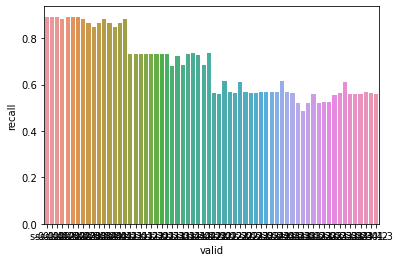

In [63]:
sns.barplot(x='valid',y='recall',data=df),

In [123]:
def get_percent(dataset):
    df = pd.read_csv(dataset,index_col=0)
    p = df[df['label']== 'benign'].shape[0]/df[df['label']== 'abnormal'].shape[0]
    count = df.shape[0]
    return p,count

In [128]:
for i in range(4):
    all_p = 0
    for j in range(1,5):
        file_name = "/data/paper/sample/s-%d-%d-3.csv"%(i,j)
        p,shape = get_percent(file_name)
        all_p = all_p + p
    p = all_p/4
    print("正负样本比例：s-%d"%i,p)

正负样本比例：s-0 1.8596757127741714
正负样本比例：s-1 0.16406577950400006
正负样本比例：s-2 1.0001349193667124
正负样本比例：s-3 1.9953101901493262


In [129]:
for b in range(4):
    for i in range(1,5):
        for j in range(4):
            file_name = "/data/paper/sample/s-%d-%d-%d.csv"%(b,i,j)
            p,count = get_percent(file_name)
            print(file_name.split("/")[-1],"数据量",count,"正负比",p)


s-0-1-0.csv 数据量 250000 正负比 2.9060669031139166
s-0-1-1.csv 数据量 50000 正负比 3.336889582791222
s-0-1-2.csv 数据量 250000 正负比 2.919601141387852
s-0-1-3.csv 数据量 500000 正负比 1.8596757127741714
s-0-2-0.csv 数据量 250000 正负比 2.8997909712039434
s-0-2-1.csv 数据量 50000 正负比 3.36871996505024
s-0-2-2.csv 数据量 250000 正负比 2.900703686945125
s-0-2-3.csv 数据量 500000 正负比 1.8596757127741714
s-0-3-0.csv 数据量 250000 正负比 1.229276644314453
s-0-3-1.csv 数据量 50000 正负比 1.0317769921573408
s-0-3-2.csv 数据量 250000 正负比 1.232681092763434
s-0-3-3.csv 数据量 500000 正负比 1.8596757127741714
s-0-4-0.csv 数据量 250000 正负比 1.2285016446342136
s-0-4-1.csv 数据量 50000 正负比 1.027903958468527
s-0-4-2.csv 数据量 250000 正负比 1.2284221879540411
s-0-4-3.csv 数据量 500000 正负比 1.8596757127741714
s-1-1-0.csv 数据量 250000 正负比 0.036540112029255306
s-1-1-1.csv 数据量 50000 正负比 0.027453559099128718
s-1-1-2.csv 数据量 250000 正负比 0.037124923771318104
s-1-1-3.csv 数据量 500000 正负比 0.16416874858844538
s-1-2-0.csv 数据量 250000 正负比 0.03697005645264987
s-1-2-1.csv 数据量 50000 正负比 0.02848914943

In [130]:
df = pd.read_csv("/data/paper/analyse/similarity.csv",index_col=0)

df

,D1,D2,Cosine,Pearson,Euclidean,EDM,KS,Manhattan,Minkowski,Jaccard
0,s-0-1-0,s-0-1-0,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000
1,s-0-1-0,s-0-1-1,0.9776,0.9773,1.4221,0.0001,0.8984,3.2705,1.2600,0.0055
2,s-0-1-0,s-0-1-2,1.0000,1.0000,0.0520,0.0000,1.0000,0.4678,0.0310,0.0046
3,s-0-1-0,s-0-1-3,0.9973,0.9972,0.5206,0.0004,0.9340,3.1379,0.3630,0.0029
4,s-0-1-0,s-0-2-0,1.0000,1.0000,0.0364,0.0000,1.0000,0.3490,0.0210,0.0031
...,...,...,...,...,...,...,...,...,...,...
1019,s-3-4-0,s-3-3-3,0.9991,0.9991,0.2635,0.0002,0.9800,1.6723,0.1660,0.0056
1020,s-3-4-0,s-3-4-0,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000
1021,s-3-4-0,s-3-4-1,0.9481,0.9477,2.0060,0.0001,0.7794,5.1784,1.5880,0.0045
1022,s-3-4-0,s-3-4-2,0.9483,0.9479,2.0008,0.0000,0.8776,4.2813,1.5870,0.0064
